# MLP Classifier for Iris Dataset

## Objective

The objective is to develop and evaluate an MLP (Multi-Layer Perceptron) classifier for the Iris dataset by comparing two different hidden-layer architectures using cross-validation.

The two architectures are:

1. One hidden layer with 10 neurons.
2. Two hidden layers with 10 and 5 neurons.

The models are evaluated using cross-validation accuracy and confusion matrices.

## 1. Import Required Libraries

The required libraries are imported for data handling, preprocessing, MLP classification, cross-validation, and model evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

## 2. Load the Iris Dataset

The Iris dataset contains 150 samples, 4 numerical features, and 3 target classes.

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Classes:", target_names)

Number of samples: 150
Number of features: 4
Classes: ['setosa' 'versicolor' 'virginica']


## 3. Preprocessing

MLP classifiers are sensitive to the scale of input features. Therefore, StandardScaler is used to standardize the features.

The scaler is included inside a Pipeline so that scaling is performed separately within each cross-validation fold, preventing data leakage.

## 4. Cross-Validation Setup

Stratified 5-fold cross-validation is used so that each fold maintains a similar proportion of the three Iris classes.

The same cross-validation strategy is used for both architectures to ensure a fair comparison.

In [3]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 5. MLP Architecture 1

The first MLP uses one hidden layer containing 10 neurons.

Architecture:

Input (4 features) → 10 neurons → Output (3 classes)

In [5]:
mlp_1 = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(10,),
        max_iter=2000,
        random_state=42
    ))
])

scores_1 = cross_val_score(
    mlp_1,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Architecture 1 Accuracy Scores:")
print(scores_1)

print("\nMean Cross-Validation Accuracy:",
      scores_1.mean())

Architecture 1 Accuracy Scores:
[1.         1.         0.86666667 1.         0.93333333]

Mean Cross-Validation Accuracy: 0.96


# 6. MLP Architecture 2

The second MLP uses two hidden layers containing 10 and 5 neurons.

Architecture:

Input (4 features) → 10 neurons → 5 neurons → Output (3 classes)

This modifies the hidden-layer architecture by increasing its depth and changing the distribution of neurons across the hidden layers.

In [7]:
mlp_2 = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(10, 5),
        max_iter=2000,
        random_state=42
    ))
])

scores_2 = cross_val_score(
    mlp_2,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Architecture 2 Accuracy Scores:")
print(scores_2)

print("\nMean Cross-Validation Accuracy:",
      scores_2.mean())

Architecture 2 Accuracy Scores:
[1.         1.         0.9        1.         0.96666667]

Mean Cross-Validation Accuracy: 0.9733333333333333


## 7. Compare Cross-Validation Accuracy

The mean cross-validation accuracy is used to compare the two hidden-layer architectures.

In [8]:
comparison = pd.DataFrame({
    "Architecture": [
        "1 Hidden Layer (10)",
        "2 Hidden Layers (10, 5)"
    ],
    "Mean CV Accuracy": [
        scores_1.mean(),
        scores_2.mean()
    ]
})

comparison

,Architecture,Mean CV Accuracy
0,1 Hidden Layer (10),0.960000
1,"2 Hidden Layers (10, 5)",0.973333


## 8. Confusion Matrix — Architecture 1

Cross-validation predictions are generated for the complete dataset using the first MLP architecture.

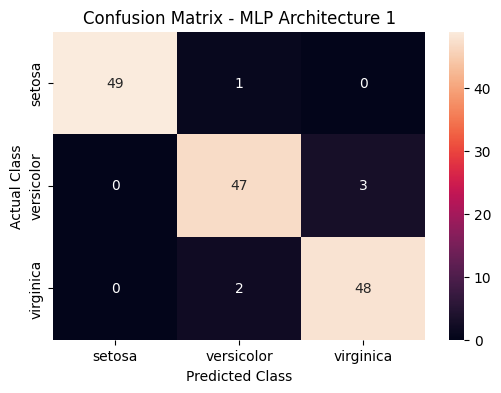

In [9]:
y_pred_1 = cross_val_predict(
    mlp_1,
    X,
    y,
    cv=cv
)

cm_1 = confusion_matrix(y, y_pred_1)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_1,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - MLP Architecture 1")
plt.show()

### Conclusion – MLP Architecture 1

Architecture 1 correctly classified 144 out of 150 samples, giving an accuracy of **96.00%**. Setosa was classified correctly in all cases. Most errors occurred between Versicolor and Virginica, indicating that these two classes are more difficult for the model to distinguish.

## 9. Confusion Matrix — Architecture 2

Cross-validation predictions are generated for the second MLP architecture.

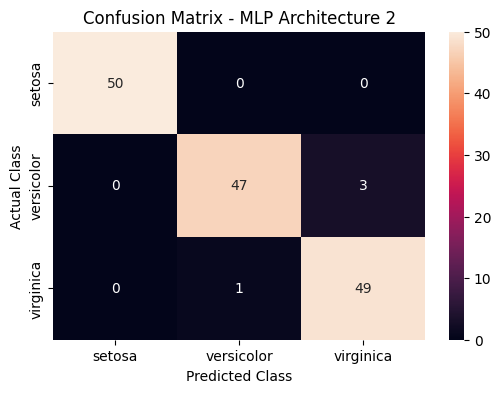

In [10]:
y_pred_2 = cross_val_predict(
    mlp_2,
    X,
    y,
    cv=cv
)

cm_2 = confusion_matrix(y, y_pred_2)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_2,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - MLP Architecture 2")
plt.show()

### Conclusion – MLP Architecture 2

Architecture 2 correctly classified 146 out of 150 samples, giving an accuracy of **97.33%**. Setosa was again classified perfectly. Compared with Architecture 1, Architecture 2 made fewer classification errors, with the remaining errors occurring only between Versicolor and Virginica.

## 10. Final Comparison

The two MLP architectures are compared using their mean 5-fold cross-validation accuracy.

The architecture with the higher mean accuracy provides better classification performance on the Iris dataset.

In [11]:
print("MLP Architecture 1 (10):")
print(f"Mean CV Accuracy: {scores_1.mean():.4f}")

print("\nMLP Architecture 2 (10, 5):")
print(f"Mean CV Accuracy: {scores_2.mean():.4f}")

MLP Architecture 1 (10):
Mean CV Accuracy: 0.9600

MLP Architecture 2 (10, 5):
Mean CV Accuracy: 0.9733


## Conclusion

Two MLP hidden-layer architectures were developed and evaluated using 5-fold stratified cross-validation.

Architecture 1 used one hidden layer with 10 neurons, while Architecture 2 used two hidden layers with 10 and 5 neurons. Feature standardization was applied because MLP classifiers are sensitive to feature scale.

The mean cross-validation accuracy and confusion matrices were used to compare the architectures. The architecture with the higher cross-validation accuracy provides better classification performance for the Iris dataset.

Thus, modifying the number and arrangement of neurons in the hidden layers can affect the classification performance of an MLP.

## Final report

The two MLP architectures were evaluated using 5-fold stratified cross-validation. Architecture 1 achieved **96.00%** accuracy, while Architecture 2 achieved **97.33%** accuracy. Therefore, Architecture 2, with two hidden layers containing 10 and 5 neurons, performed slightly better than Architecture 1 with one hidden layer of 10 neurons. Both architectures classified Setosa correctly in all cases, while most errors involved distinguishing Versicolor from Virginica.